# SVM Analysis

### Load dataset

In [1]:
import numpy as np
import struct 

def read_images(filepath):
    with open(filepath, 'rb') as f:
        magic, num, rows, cols = struct.unpack(">IIII", f.read(16))
        images = np.frombuffer(f.read(), dtype=np.uint8).reshape(num, 28, 28)
    return images

def read_labels(filepath):
    with open(filepath, 'rb') as f:
        magic, num = struct.unpack(">II", f.read(8))
        labels = np.frombuffer(f.read(), dtype=np.uint8)
    return labels

imgs_train = read_images(r"C:\Users\jenni\Downloads\Datasets\train-images.idx3-ubyte")
imgs_test = read_images(r"C:\Users\jenni\Downloads\Datasets\t10k-images.idx3-ubyte")

labels_train = read_labels(r"C:\Users\jenni\Downloads\Datasets\train-labels.idx1-ubyte")
labels_test = read_labels(r"C:\Users\jenni\Downloads\Datasets\t10k-labels.idx1-ubyte")

imgs_svm = np.vstack([imgs_train, imgs_test])
labels_svm = np.hstack([labels_train, labels_test])

print(imgs_svm.shape)
print(labels_svm.shape)

(70000, 28, 28)
(70000,)


### Dataset split 

In [2]:
from sklearn.model_selection import train_test_split

# train, test, valid
SPLITS = {
    "train": 0.7,
    "val": 0.2,
    "test": 0.1,
}

train_test_imgs, val_imgs, train_test_labels, val_labels = train_test_split(imgs_svm, labels_svm, test_size=SPLITS["val"])
train_imgs, test_imgs, train_labels, test_labels = train_test_split(train_test_imgs, train_test_labels, test_size=SPLITS["test"] / (SPLITS["train"] + SPLITS["test"]))

### Scaler

In [3]:
from sklearn.preprocessing import StandardScaler

scaler_svm = StandardScaler()
train_images_scaled = scaler_svm.fit_transform(train_imgs.reshape((-1, 28 * 28)))
val_images_scaled = scaler_svm.transform(val_imgs.reshape((-1, 28 * 28)))

### Using SVC as model

##### C-Support Vector Classification.

##### The implementation is based on libsvm. The fit time scales at least quadratically with the number of samples and may be impractical beyond tens of thousands of samples. 

#### C -> Regularization parameter. The strength of the regularization is inversely proportional to C.

##### The goal is to test a range of values to find the best C value for this case

C=1e-05 -- Erro = 0.1212
C=0.0001 -- Erro = 0.0784
C=0.001 -- Erro = 0.0626
C=0.01 -- Erro = 0.0604
C=0.1 -- Erro = 0.0693
C=1.0 -- Erro = 0.0776
C=10.0 -- Erro = 0.0836
C=100.0 -- Erro = 0.0862


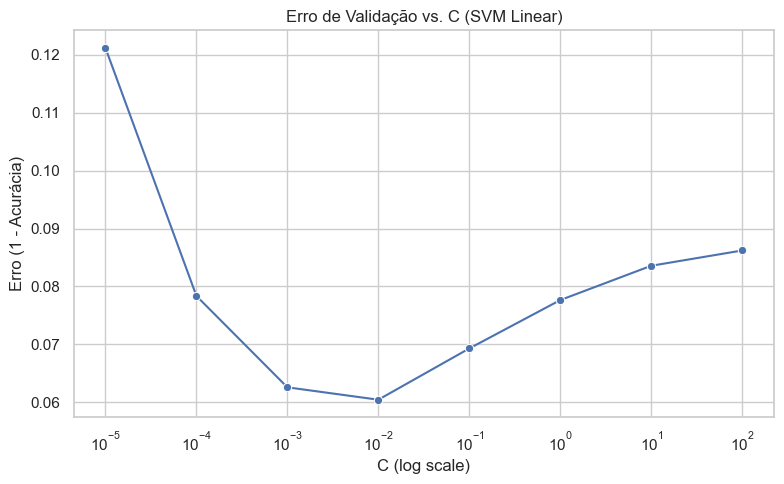

In [5]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

C_values = np.logspace(-5, 2, num=8)
errors = []

for C in C_values:
    model = SVC(kernel='linear', C=C)
    model.fit(train_images_scaled, train_labels)
    pred_labels = model.predict(val_images_scaled)
    error_score = 1 - accuracy_score(val_labels, pred_labels)
    errors.append(error_score)
    print(f"C={C} -- Erro = {error_score:.4f}")

sns.set(style="whitegrid")
plt.figure(figsize=(8, 5))
sns.lineplot(x=C_values, y=errors, marker='o')
plt.xscale('log')
plt.xlabel("C (log scale)")
plt.ylabel("Erro (1 - Acurácia)")
plt.title("Erro de Validação vs. C (SVM Linear)")
plt.tight_layout()
plt.show()

##### Best C value

In [6]:
best_index = np.argmin(errors)
best_c = C_values[best_index]
print(f"\nMelhor C: {best_c} com erro = {errors[best_index]:.4f}")


Melhor C: 0.01 com erro = 0.0604


### Next test: using different kernels

#### kernel{‘linear’, ‘poly’, ‘rbf’, ‘sigmoid’, ‘precomputed’} or callable, default=’rbf’

#### Specifies the kernel type to be used in the algorithm. If none is given, ‘rbf’ will be used.


Kernel=linear -- Erro = 0.0604
Kernel=poly -- Erro = 0.6735
Kernel=rbf -- Erro = 0.1504
Kernel=sigmoid -- Erro = 0.1161


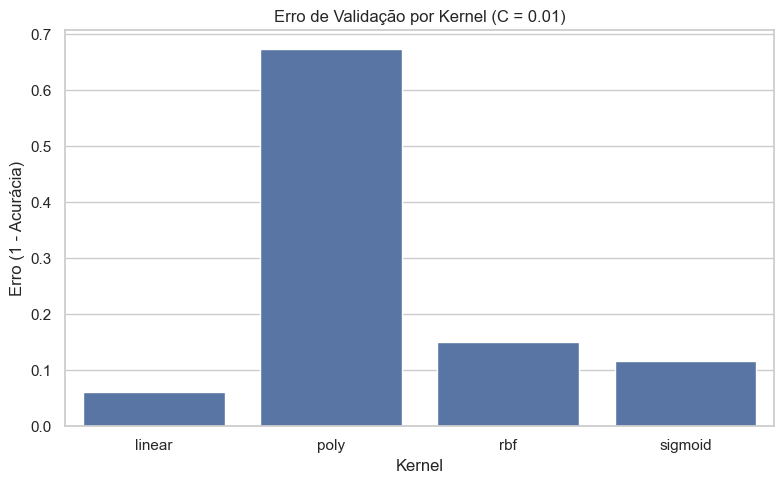

In [7]:
kernels = ['linear', 'poly', 'rbf', 'sigmoid']
errors_kernel = []

for kernel in kernels:
    model = SVC(kernel=kernel, C=best_c)
    model.fit(train_images_scaled, train_labels)
    pred_labels = model.predict(val_images_scaled)
    error_score = 1 - accuracy_score(val_labels, pred_labels)
    errors_kernel.append(error_score)
    print(f"Kernel={kernel} -- Erro = {error_score:.4f}")

sns.set(style="whitegrid")
plt.figure(figsize=(8, 5))
sns.barplot(x=kernels, y=errors_kernel)
plt.xlabel("Kernel")
plt.ylabel("Erro (1 - Acurácia)")
plt.title(f"Erro de Validação por Kernel (C = {best_c})")
plt.tight_layout()
plt.show()

##### Best Kernel

In [8]:
best_index_kernel = np.argmin(errors_kernel)
best_kernel = kernels[best_index_kernel]

print(f"\nMelhor kernel: {best_kernel} com erro = {errors_kernel[best_index_kernel]:.4f}")


Melhor kernel: linear com erro = 0.0604


### Testing different gamma values 

#### gamma{‘scale’, ‘auto’} or float, default=’scale’
#### Kernel coefficient for ‘rbf’, ‘poly’ and ‘sigmoid’.

Gamma=0.001 -- Erro = 0.0604
Gamma=0.01 -- Erro = 0.0604
Gamma=0.1 -- Erro = 0.0604
Gamma=1 -- Erro = 0.0604
Gamma=10 -- Erro = 0.0604


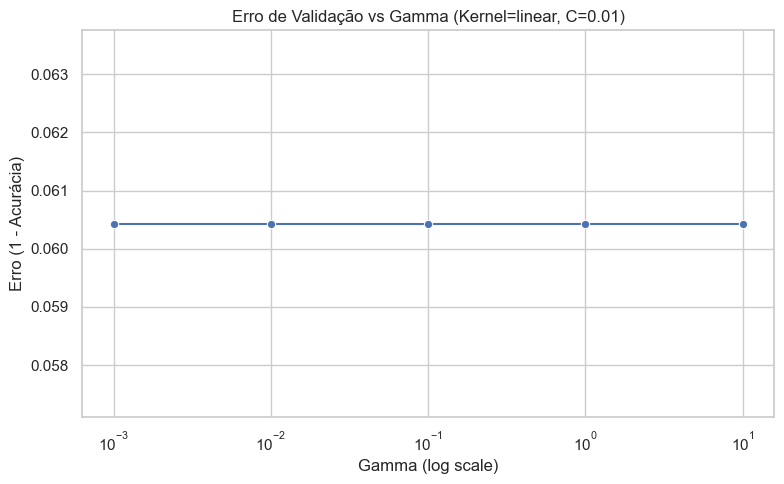

In [9]:
gammas = [0.001, 0.01, 0.1, 1, 10]
errors_gamma = []

for gamma in gammas:
    model = SVC(kernel=best_kernel, C=best_c, gamma=gamma)
    model.fit(train_images_scaled, train_labels)
    pred_labels = model.predict(val_images_scaled)
    error_score = 1 - accuracy_score(val_labels, pred_labels)
    errors_gamma.append(error_score)
    print(f"Gamma={gamma} -- Erro = {error_score:.4f}")
    
sns.set(style="whitegrid")
plt.figure(figsize=(8, 5))
sns.lineplot(x=gammas, y=errors_gamma, marker='o')
plt.xscale('log')
plt.xlabel('Gamma (log scale)')
plt.ylabel('Erro (1 - Acurácia)')
plt.title(f'Erro de Validação vs Gamma (Kernel={best_kernel}, C={best_c})')
plt.tight_layout()
plt.show()

##### Best Gamma value

In [10]:
best_index_gamma = np.argmin(errors_gamma)
best_gamma = gammas[best_index_gamma]
print(f"\nMelhor gamma: {best_gamma} com erro = {errors_gamma[best_index_gamma]:.4f}")


Melhor gamma: 0.001 com erro = 0.0604


### Testing using best values found

In [11]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

params = dict(kernel=best_kernel, C=best_c)
if best_kernel in ['rbf', 'poly', 'sigmoid']:
    params['gamma'] = best_gamma

model_final = SVC(**params)
model_final.fit(train_images_scaled, train_labels)

val_preds = model_final.predict(val_images_scaled)
val_acc = accuracy_score(val_labels, val_preds)
print(f"Acurácia na Validação: {val_acc:.4f}")

test_images_scaled = scaler_svm.transform(test_imgs.reshape((-1, 28*28)))
test_preds = model_final.predict(test_images_scaled)
test_acc = accuracy_score(test_labels, test_preds)
print(f"Acurácia no Teste: {test_acc:.4f}")

Acurácia na Validação: 0.9396
Acurácia no Teste: 0.9407


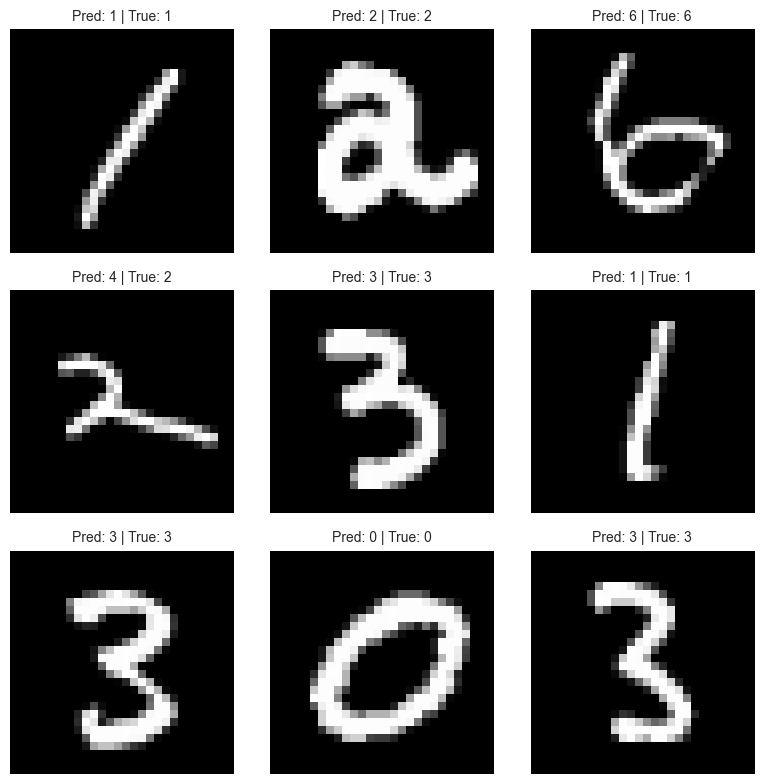

In [12]:
indices = np.random.choice(len(test_imgs), 9, replace=False)

plt.figure(figsize=(8, 8))
for i, idx in enumerate(indices):
    img = test_imgs[idx]
    pred = test_preds[idx]
    true = test_labels[idx]
    
    plt.subplot(3, 3, i + 1)
    plt.imshow(img, cmap='gray')
    plt.title(f'Pred: {pred} | True: {true}', fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()

### Testing using best gamma value


In [13]:
model_final = SVC(C=best_c, kernel='rbf', gamma=best_gamma)
model_final.fit(train_images_scaled, train_labels)

val_preds = model_final.predict(val_images_scaled)
val_acc = accuracy_score(val_labels, val_preds)
print(f"Acurácia na Validação: {val_acc:.4f}")

test_images_scaled = scaler_svm.transform(test_imgs.reshape((-1, 28*28)))
test_preds = model_final.predict(test_images_scaled)
test_acc = accuracy_score(test_labels, test_preds)
print(f"Acurácia no Teste: {test_acc:.4f}")

Acurácia na Validação: 0.8566
Acurácia no Teste: 0.8562


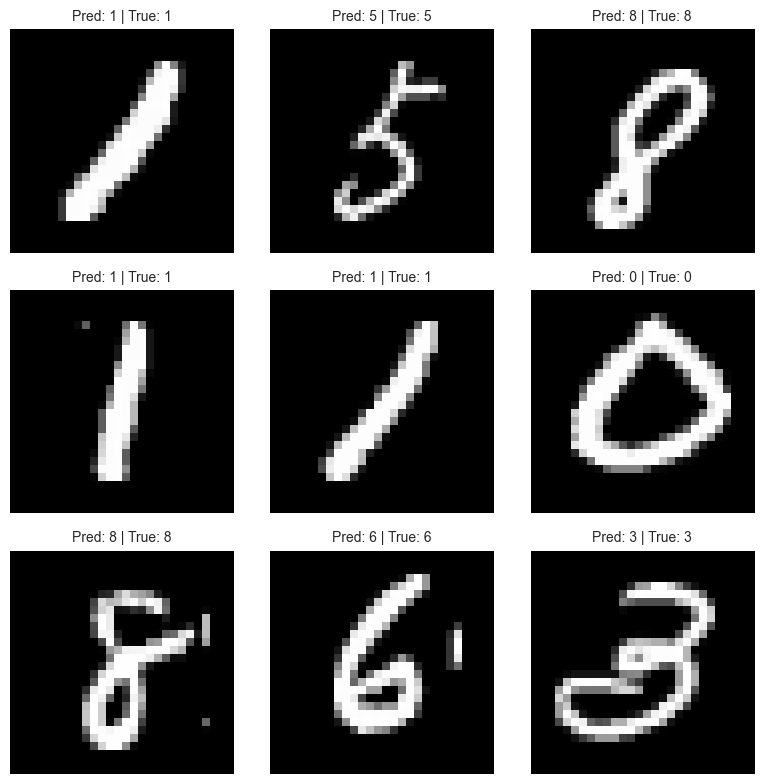

In [14]:
indices = np.random.choice(len(test_imgs), 9, replace=False)

plt.figure(figsize=(8, 8))
for i, idx in enumerate(indices):
    img = test_imgs[idx]
    pred = test_preds[idx]
    true = test_labels[idx]
    
    plt.subplot(3, 3, i + 1)
    plt.imshow(img, cmap='gray')
    plt.title(f'Pred: {pred} | True: {true}', fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()

### Testing different splits using the same best values

##### First test

In [15]:
SPLITS = {
    "train": 0.8,
    "val": 0.1,
    "test": 0.1,
}

train_test_imgs, val_imgs, train_test_labels, val_labels = train_test_split(imgs_svm, labels_svm, test_size=SPLITS["val"])
train_imgs, test_imgs, train_labels, test_labels = train_test_split(train_test_imgs, train_test_labels, test_size=SPLITS["test"] / (SPLITS["train"] + SPLITS["test"]))

scaler_svm = StandardScaler()
train_images_scaled = scaler_svm.fit_transform(train_imgs.reshape((-1, 28 * 28)))
val_images_scaled = scaler_svm.transform(val_imgs.reshape((-1, 28 * 28)))

In [16]:
params = dict(kernel=best_kernel, C=best_c)
if best_kernel in ['rbf', 'poly', 'sigmoid']:
    params['gamma'] = best_gamma

model_final = SVC(**params)
model_final.fit(train_images_scaled, train_labels)

val_preds = model_final.predict(val_images_scaled)
val_acc = accuracy_score(val_labels, val_preds)
print(f"Acurácia na Validação: {val_acc:.4f}")

test_images_scaled = scaler_svm.transform(test_imgs.reshape((-1, 28*28)))
test_preds = model_final.predict(test_images_scaled)
test_acc = accuracy_score(test_labels, test_preds)
print(f"Acurácia no Teste: {test_acc:.4f}")

Acurácia na Validação: 0.9474
Acurácia no Teste: 0.9406


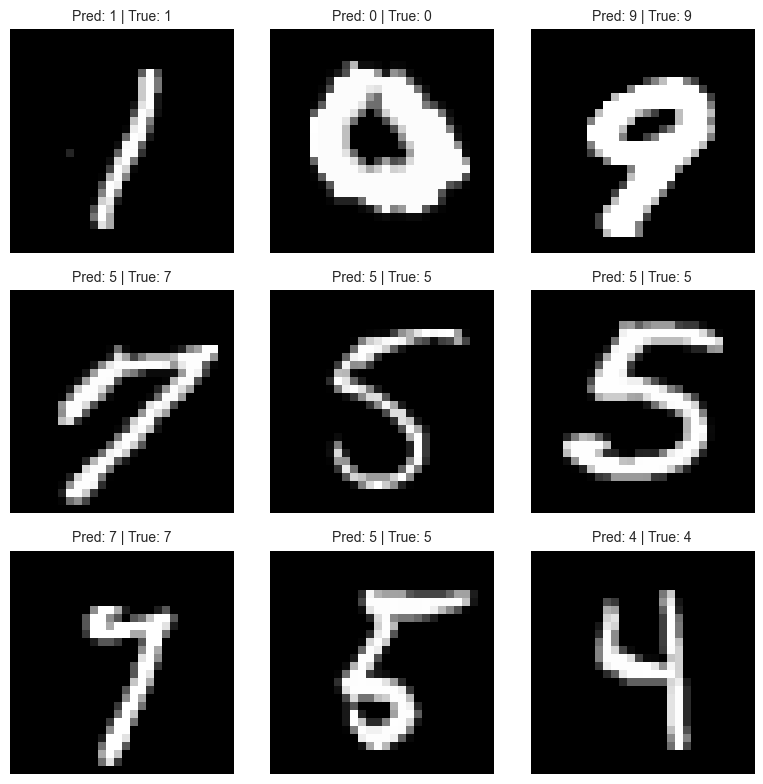

In [17]:
indices = np.random.choice(len(test_imgs), 9, replace=False)

plt.figure(figsize=(8, 8))
for i, idx in enumerate(indices):
    img = test_imgs[idx]
    pred = test_preds[idx]
    true = test_labels[idx]
    
    plt.subplot(3, 3, i + 1)
    plt.imshow(img, cmap='gray')
    plt.title(f'Pred: {pred} | True: {true}', fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()

##### Second test

In [18]:
SPLITS = {
    "train": 0.6,
    "val": 0.2,
    "test": 0.2,
}

train_test_imgs, val_imgs, train_test_labels, val_labels = train_test_split(imgs_svm, labels_svm, test_size=SPLITS["val"])
train_imgs, test_imgs, train_labels, test_labels = train_test_split(train_test_imgs, train_test_labels, test_size=SPLITS["test"] / (SPLITS["train"] + SPLITS["test"]))

scaler_svm = StandardScaler()
train_images_scaled = scaler_svm.fit_transform(train_imgs.reshape((-1, 28 * 28)))
val_images_scaled = scaler_svm.transform(val_imgs.reshape((-1, 28 * 28)))

In [19]:
params = dict(kernel=best_kernel, C=best_c)
if best_kernel in ['rbf', 'poly', 'sigmoid']:
    params['gamma'] = best_gamma

model_final = SVC(**params)
model_final.fit(train_images_scaled, train_labels)

val_preds = model_final.predict(val_images_scaled)
val_acc = accuracy_score(val_labels, val_preds)
print(f"Acurácia na Validação: {val_acc:.4f}")

test_images_scaled = scaler_svm.transform(test_imgs.reshape((-1, 28*28)))
test_preds = model_final.predict(test_images_scaled)
test_acc = accuracy_score(test_labels, test_preds)
print(f"Acurácia no Teste: {test_acc:.4f}")

Acurácia na Validação: 0.9379
Acurácia no Teste: 0.9417


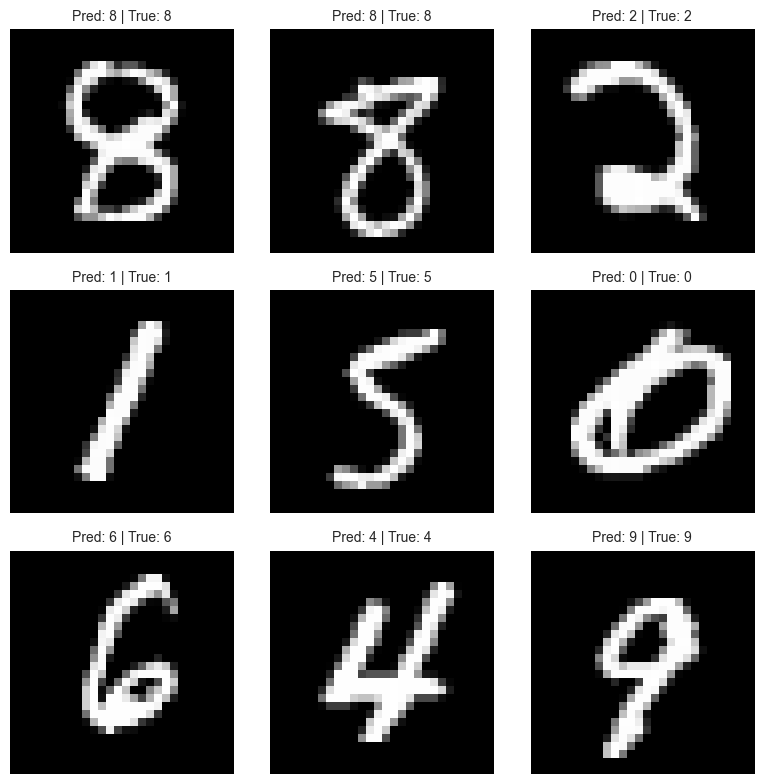

In [20]:
indices = np.random.choice(len(test_imgs), 9, replace=False)

plt.figure(figsize=(8, 8))
for i, idx in enumerate(indices):
    img = test_imgs[idx]
    pred = test_preds[idx]
    true = test_labels[idx]
    
    plt.subplot(3, 3, i + 1)
    plt.imshow(img, cmap='gray')
    plt.title(f'Pred: {pred} | True: {true}', fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()